##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Resize, Compose

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import scalarConditionedNetworkCNN, scalarConditionedNetworkUNet, timeConditionedField, continuousNormFlow
from svipy.normflow import identityTimeEmbedding, fourierTimeEmbedding, filmTimeEmbedding
from svipy.diffusion import linearConditionalPath, reversedConditionalPath, conditionalFlowMatcher
from svipy.diffusion import varPreservingConditionalPathTrigonometric, varPreservingConditionalPathDDPMCosine
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Compose([Resize(32), Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))])

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


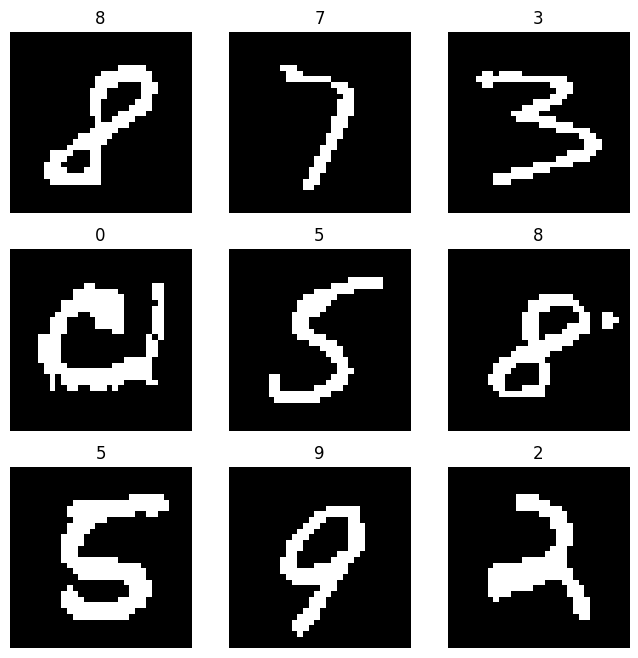

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### Conditional Flow Matching

###### Optimal transport paths

In [6]:
tcn = scalarConditionedNetworkCNN(1, [(32, 5), (32, 5), (32, 5), (32, 5), (32, 5), (32, 5)], t_dim=1) 
embed = identityTimeEmbedding()
tcf = timeConditionedField(tcn, embed)

path = linearConditionalPath()

model_cfm_ot = conditionalFlowMatcher(path, tcf).to(device)

In [7]:
learning_rate = 0.001
batch_size = 128
epochs = 200

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_cfm_ot.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.1, mode='min', restoreBestWeights=True)

In [8]:
%%time 
model_cfm_ot.trainLoop(trainLoader, optimizer, epochs, 
                       reportIters=100, scheduler=None,
                       checkpointPath='../checkpoints/mnist_cfm/',
                       checkPointName='cfm_ot',
                       validDataLoader=validLoader,
                       earlyStopper=stopper
                      )

Epoch 1
-------------------------------
totalLoss: 265.304199[12800/60000]
totalLoss: 205.941193[25600/60000]
totalLoss: 192.055161[38400/60000]
totalLoss: 160.549438[51200/60000]
Validation Error: 169.516438
Epoch 2
-------------------------------
totalLoss: 159.251923[12800/60000]
totalLoss: 166.143921[25600/60000]
totalLoss: 134.173126[38400/60000]
totalLoss: 129.181183[51200/60000]
Validation Error: 134.015972
Epoch 3
-------------------------------
totalLoss: 131.044281[12800/60000]
totalLoss: 135.006378[25600/60000]
totalLoss: 141.523132[38400/60000]
totalLoss: 121.529442[51200/60000]
Validation Error: 122.429826
Epoch 4
-------------------------------
totalLoss: 125.778885[12800/60000]
totalLoss: 115.379501[25600/60000]
totalLoss: 114.450027[38400/60000]
totalLoss: 125.343185[51200/60000]
Validation Error: 115.290068
Epoch 5
-------------------------------
totalLoss: 122.972305[12800/60000]
totalLoss: 118.202538[25600/60000]
totalLoss: 123.503143[38400/60000]
totalLoss: 118.9757

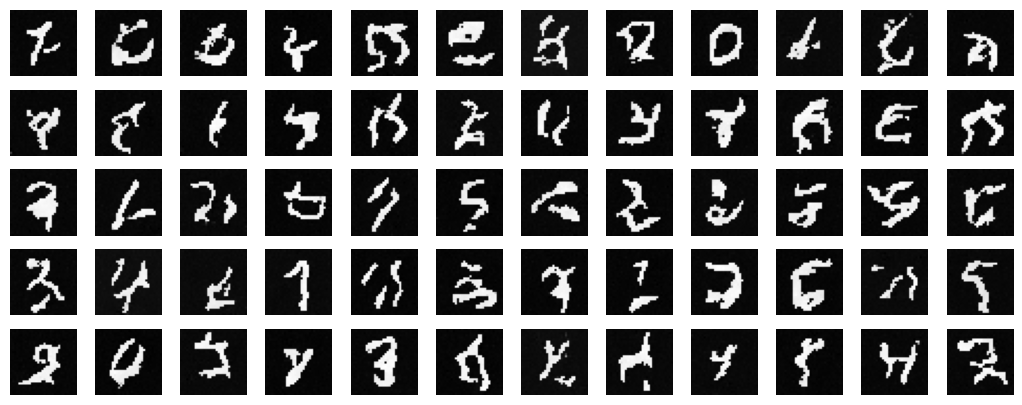

In [9]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf)

idxs = []

with torch.no_grad():
    for i in range(nCols * nRows):
        x0 = torch.randn([1, 1, 32, 32]).to(device)
        
        img = cnf.generate(x0)[0].cpu().detach()
        img = img.numpy().squeeze()
        
        figure.add_subplot(nRows, nCols, i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')

plt.show()

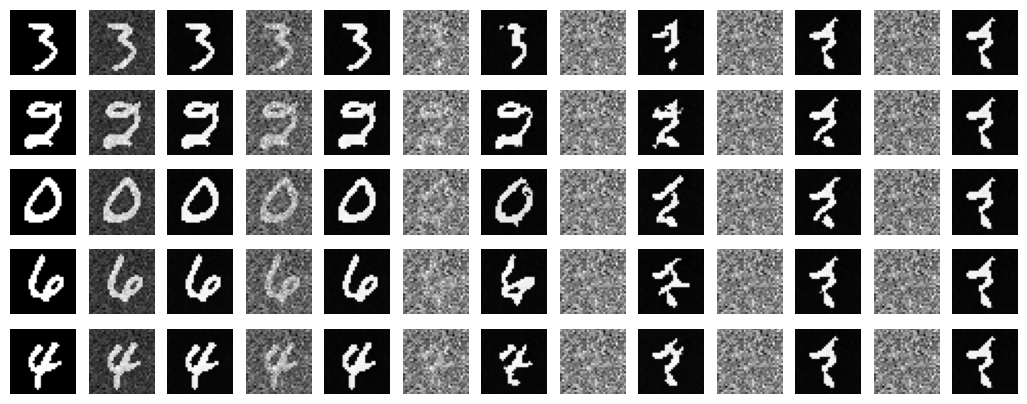

In [10]:
nCols = 13
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf).to(device)

idxs = []
tx = [0.9, 0.75, 0.5, 0.25, 0.1, 0.0]

sidx = torch.randint(len(trainData), size=(1,)).item()
x1, _ = trainData[sidx]
x0 = torch.randn_like(x1).to(device)  # sample a single noise image

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        x1, label = trainData[sidx]

        # original image
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(x1.squeeze(), cmap='gray')

        x1 = x1.unsqueeze(0).to(device)        
        for j, txj in enumerate(tx):
            # interpolated
            xt, _ = path(x0, x1, torch.tensor([txj]).to(device))
            img = xt.cpu().detach().numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 2)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

            # generated
            img = cnf.interpolate(xt, txj, 1.)[0].cpu().detach()
            img = img.numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 3)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

plt.show()

###### VAR preserving paths

In [11]:
tcn = scalarConditionedNetworkCNN(1, [(32, 5), (32, 5), (32, 5), (32, 5), (32, 5), (32, 5)], t_dim=8) 
embed = fourierTimeEmbedding(8)
tcf = timeConditionedField(tcn, embed)

path = reversedConditionalPath(varPreservingConditionalPathTrigonometric(target='velocity'))

model_cfm_varp = conditionalFlowMatcher(path, tcf).to(device)

In [12]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_cfm_varp.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.1, mode='min', restoreBestWeights=True)

In [13]:
%%time 
model_cfm_varp.trainLoop(trainLoader, optimizer, epochs, 
                         reportIters=100, scheduler=None,
                         checkpointPath='../checkpoints/mnist_cfm/',
                         checkPointName='cfm_varp',
                         validDataLoader=validLoader,
                         earlyStopper=stopper
                        )

Epoch 1
-------------------------------
totalLoss: 703.617798[12800/60000]
totalLoss: 521.735840[25600/60000]
totalLoss: 368.351257[38400/60000]
totalLoss: 340.704163[51200/60000]
Validation Error: 314.470447
Epoch 2
-------------------------------
totalLoss: 285.652313[12800/60000]
totalLoss: 272.482605[25600/60000]
totalLoss: 232.782669[38400/60000]
totalLoss: 232.243698[51200/60000]
Validation Error: 227.121764
Epoch 3
-------------------------------
totalLoss: 230.133026[12800/60000]
totalLoss: 218.624283[25600/60000]
totalLoss: 202.343506[38400/60000]
totalLoss: 208.454132[51200/60000]
Validation Error: 200.090610
Epoch 4
-------------------------------
totalLoss: 211.705933[12800/60000]
totalLoss: 198.417038[25600/60000]
totalLoss: 174.866394[38400/60000]
totalLoss: 178.678146[51200/60000]
Validation Error: 196.622533
Epoch 5
-------------------------------
totalLoss: 190.967834[12800/60000]
totalLoss: 223.596985[25600/60000]
totalLoss: 181.951111[38400/60000]
totalLoss: 186.5317

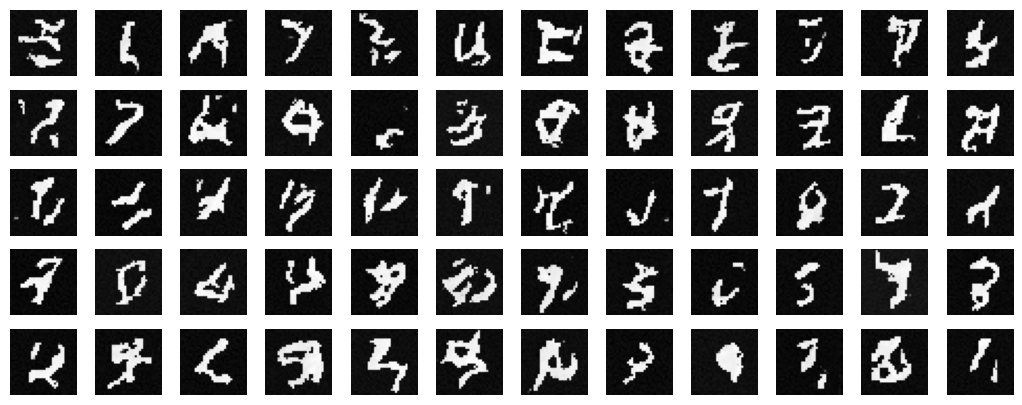

In [14]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf)

idxs = []

with torch.no_grad():
    for i in range(nCols * nRows):
        x0 = torch.randn([1, 1, 32, 32]).to(device)
        
        img = cnf.generate(x0)[0].cpu().detach()
        img = img.numpy().squeeze()
        
        figure.add_subplot(nRows, nCols, i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')

plt.show()

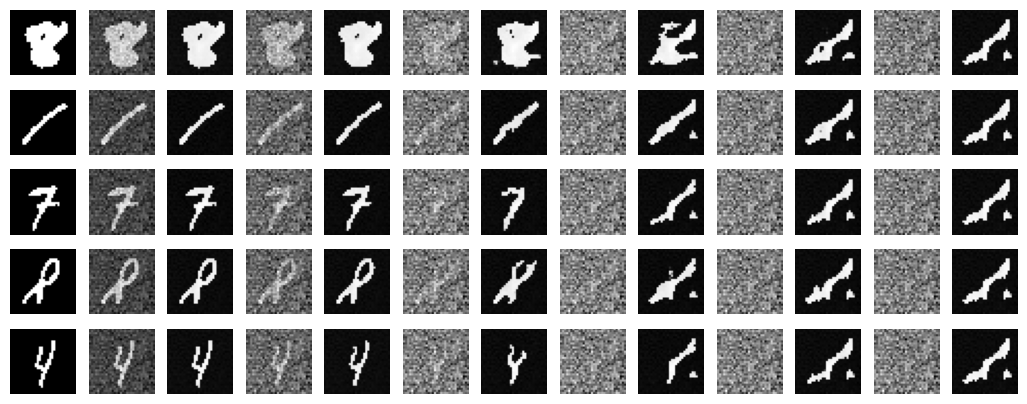

In [15]:
nCols = 13
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf).to(device)

idxs = []
tx = [0.9, 0.75, 0.5, 0.25, 0.1, 0.0]

sidx = torch.randint(len(trainData), size=(1,)).item()
x1, _ = trainData[sidx]
x0 = torch.randn_like(x1).to(device)  # sample a single noise image

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        x1, label = trainData[sidx]

        # original image
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(x1.squeeze(), cmap='gray')

        x1 = x1.unsqueeze(0).to(device)        
        for j, txj in enumerate(tx):
            # interpolated
            xt, _ = path(x0, x1, torch.tensor([txj]).to(device))
            img = xt.cpu().detach().numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 2)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

            # generated
            img = cnf.interpolate(xt, txj, 1.)[0].cpu().detach()
            img = img.numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 3)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

plt.show()

###### UNet Architecture

In [16]:
tcn = scalarConditionedNetworkUNet(1, [32, 32, 32, 32], t_dim=0) 
embed = filmTimeEmbedding(tcn.filmDims())
tcf = timeConditionedField(tcn, embed)

path = linearConditionalPath()

model_cfm_unet = conditionalFlowMatcher(path, tcf).to(device)

In [17]:
learning_rate = 0.001
batch_size = 128
epochs = 200

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_cfm_unet.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.1, mode='min', restoreBestWeights=True)

In [18]:
%%time 
model_cfm_unet.trainLoop(trainLoader, optimizer, epochs, 
                         reportIters=100, scheduler=None,
                         checkpointPath='../checkpoints/mnist_cfm/',
                         checkPointName='cfm_unet',
                         validDataLoader=validLoader,
                         earlyStopper=stopper
                        )

Epoch 1
-------------------------------
totalLoss: 315.385925[12800/60000]
totalLoss: 234.122589[25600/60000]
totalLoss: 227.363892[38400/60000]
totalLoss: 194.460999[51200/60000]
Validation Error: 178.524807
Epoch 2
-------------------------------
totalLoss: 162.276093[12800/60000]
totalLoss: 168.996246[25600/60000]
totalLoss: 153.703583[38400/60000]
totalLoss: 154.367310[51200/60000]
Validation Error: 147.923226
Epoch 3
-------------------------------
totalLoss: 141.879517[12800/60000]
totalLoss: 156.195190[25600/60000]
totalLoss: 131.761932[38400/60000]
totalLoss: 148.864883[51200/60000]
Validation Error: 133.392047
Epoch 4
-------------------------------
totalLoss: 132.830658[12800/60000]
totalLoss: 129.554169[25600/60000]
totalLoss: 134.700562[38400/60000]
totalLoss: 121.939438[51200/60000]
Validation Error: 124.442883
Epoch 5
-------------------------------
totalLoss: 123.464371[12800/60000]
totalLoss: 142.100021[25600/60000]
totalLoss: 116.481583[38400/60000]
totalLoss: 119.3688

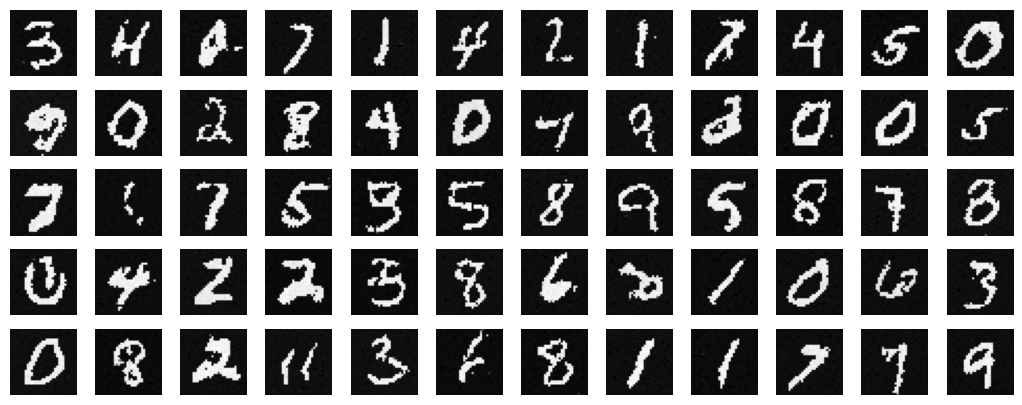

In [19]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf)

idxs = []

with torch.no_grad():
    for i in range(nCols * nRows):
        x0 = torch.randn([1, 1, 32, 32]).to(device)
        
        img = cnf.generate(x0)[0].cpu().detach()
        img = img.numpy().squeeze()
        
        figure.add_subplot(nRows, nCols, i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')

plt.show()

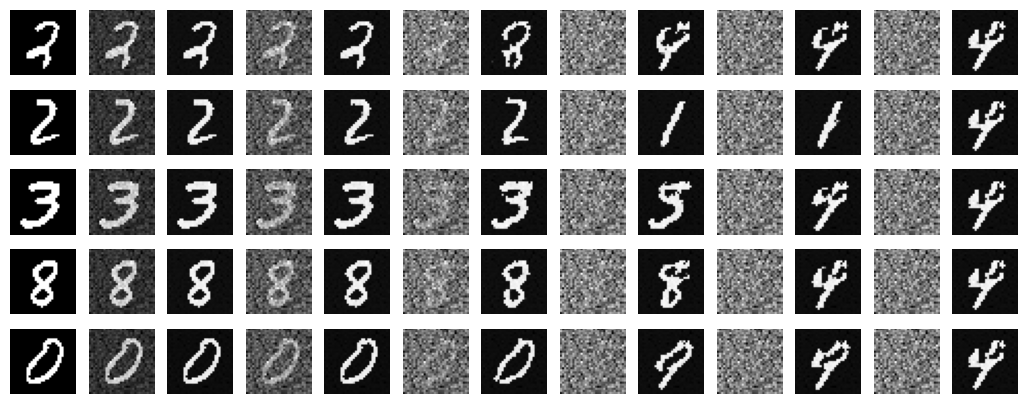

In [20]:
nCols = 13
nRows = 5

figure = plt.figure(figsize=(13, 5))
tcf.eval()
cnf = continuousNormFlow(tcf).to(device)

idxs = []
tx = [0.9, 0.75, 0.5, 0.25, 0.1, 0.0]

sidx = torch.randint(len(trainData), size=(1,)).item()
x1, _ = trainData[sidx]
x0 = torch.randn_like(x1).to(device)  # sample a single noise image

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        x1, label = trainData[sidx]

        # original image
        figure.add_subplot(nRows, nCols, nCols * i + 1)
        plt.axis("off")
        plt.imshow(x1.squeeze(), cmap='gray')

        x1 = x1.unsqueeze(0).to(device)        
        for j, txj in enumerate(tx):
            # interpolated
            xt, _ = path(x0, x1, torch.tensor([txj]).to(device))
            img = xt.cpu().detach().numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 2)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

            # generated
            img = cnf.interpolate(xt, txj, 1.)[0].cpu().detach()
            img = img.numpy().squeeze()
            figure.add_subplot(nRows, nCols, nCols * i + 2 * j + 3)
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap='gray')

plt.show()